# Peak fitting

Many data sets require identifying the location and width of a peak in the data.  Particularly in spectroscopy, where the shape of the peak is relevant, fitting a model to the peak is a good way to extract information.

### Fitting lines from a spectrum, and comparing fits

We'll load in data for a real Raman spectrum of the mineral magnesite (https://rruff.info/Magnesite/R050676) and fit some of the lines.  We'll compare fits to see which of two possible functional forms is a better fit to the line profile. 

First let's just get the data and see what we're working with.  As usual, we can use `np.loadtxt` for unpacking text/csv data.  It's often simplest to go ahead and assign columns from this to separate variable names right away, e.g. if you read in a two-column datafile into array $A$, you may then want to do `x = A[:, 0]` and `y = A[:, 1]`.  (Remember that in `numpy` arrays, the *second* dimension refers to columns.  So that line `x = A[:, 0]` means "take every row from A, but only column 0".)

#### Getting started

Import the Raman spectrum for the mineral magnesite from the file Magnesite.txt using `np.loadtxt` and then plot the entire spectrum.  The $y$ axis is normalized intensity information.  The $x$ axis represents the "Raman shift" associated with vibrational energy level differences and is in units of cm$^{-1}$.  Inverse centimeters are called "wavenumbers", and are a unit describing the inverse wavelength of light (how many waves per meter) - they are more common in chemistry than physics, but spectroscopists of all sorts use them.

Once you've plotted the whole spectrum, select a subset of data around one of the strong spectral lines, and plot only that line - that's a line we'll use for fitting in the next step.  Save the $x$ and $y$ values for this line in separate arrays for use next.

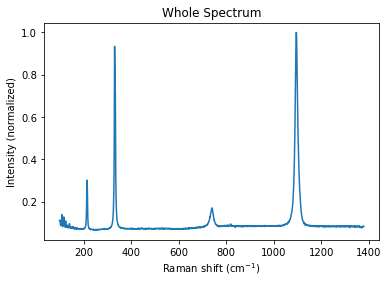

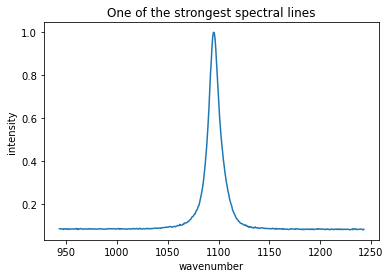

In [1]:
import numpy as np
import matplotlib.pyplot as plt

wavenumber, amplitude = np.loadtxt('Magnesite.txt', unpack=True)
plt.plot(wavenumber, amplitude)
plt.xlabel('Raman shift (cm$^{-1}$)')
plt.ylabel('Intensity (normalized)')
plt.title('Whole Spectrum')
plt.show()

plt.title('One of the strongest spectral lines')
max_amp_index = np.argmax(amplitude)
one_large_line_wavenumber = wavenumber[max_amp_index - 200:max_amp_index + 200]
one_large_line_amplitude = amplitude[max_amp_index - 200:max_amp_index + 200]
plt.xlabel('wavenumber')
plt.ylabel('intensity')
plt.plot(one_large_line_wavenumber, one_large_line_amplitude)
plt.show()

####  Exercise 1

Now let's try fitting one of the lines in this spectrum.  

First we'll try fitting the line with a Gaussian function.  Create a function that takes as arguments the central frequency, peak amplitude, and width of the Gaussian, as well as a constant additive offset (since we can see above that the background level doesn't go all the way down to zero).  It also needs to take as its first argument the independent variable, the frequency.  Use `scipy.optimize.curve_fit()` to fit the Gaussian.  You may need to make an initial guess using the `p0=` argument.

Though it's optional, before running the fitting, but after writing your Gaussian function, it's a good idea to just calculate and plot the function, to make sure that it is behaving as you expect.  Once it looks good with you manually specifying the parameters, you can go ahead and run the fit to find the best-fitting parameters.  This manual running of your function is also a good way to determine some good initial guesses for the parameters, which can be helpful to allow the fit to converge quickly to the optimal solution. 

Print the fit parameters and plot the data and its fit. 

#### Exercise 2

Now do the same exercise as above but define a function to calculate a Lorentzian 
line profile, which has the functional form

$L = \frac{1}{2\pi} \frac{w}{(\nu - \nu_0)^2 + (w/2)^2}$

where $w$ is the width of the line and $\nu_0$ is its central frequency.   As before, allow a multiplicative
scaling amplitude and a constant additive offset.

### Goodness of fit

Now, which of these functions is more appropriate for our dataset?  A Lorentzian profile is expected theoretically if the main line broadening mechanism is the energy uncertainty from the Heisenberg uncertainty principle.   A Gaussian profile is expected if the main thing broadending the line is Doppler shift due to the random motions of individual atoms.  So determining the best-fit profile can tell us something about the physical situation in the gas. 

Your eye can probably tell you already which is the better fit, but it's worth using a quantitative tool. The most common way to do this is by calculating a statistic called $\chi^2$ (pronounced "chi squared").  There are many different definitions of this statistic, beginning with just summing up the squared deviations between the data and fit:

$\chi_{basic}^2 = \Sigma (y_{data,i} - y_{fit,i})^2$

where the sum is over all the data points.  A smaller $\chi^2$ indicates a better fit.

More commonly, the statistic is weighted: each $y_i$ data point has an uncertainty $\sigma_i$ and we use these to weight the sum:

$\chi^2 = \Sigma \frac{(y_{data,i} - y_{fit,i})^2}{\sigma_i^2}.$

The effect of the weighting is that the sum is affected less by points far from the expected value if they have large uncertainties.

In my anecdotal experience, the reduced $\chi^2$ defined in Taylor is the most commonly used.  This statistic is:

$\tilde{\chi}^2 = \chi^2/d,$

where $d$ represents the number of degrees of freedom in the fit or comparison.

#### Exercise 3

Write a function to calculate the reduced $\chi^2$ and call it to print the $\tilde{\chi}^2$ value for each of your two fits above.  Use an uncertainty of 1% for the measured intensity values (arbitrary units).  Which is a better fit, a Lorentzian or a Gaussian?  Which physical mechanism seems dominant for generating the shape of this spectral line?

#### Exercise 4 (optional)

Now that we have a good fit for our data, what would the signal (which is currently in the frequency domain) look like in the time domain?  Take the inverse Fourier transform of your fit to the Raman data and plot it. We'll need to convert our frequency units from cm$^{-1}$ to Hz.  Note that we are really plotting versus a frequency in units of cm$^{-1}$ ($1/\lambda$)rather than a wavenumber.  Since light is defined by the dispersion relation $\omega = ck$, we can write a unit equation like this:
$2\pi$[Hz] = c[m/s]100[cm/m] $2\pi$[cm$^{-1}$]
That means we can convert from cm$^{-1}$ to Hz by multiplying by 100$c$.

In the case of Magnesite, the 1095 cm$^{-1}$ and 735 cm$^{-1}$ peaks are associated with stretching and bending of the carbonate group in Magnesite, and the other two main peaks are associated with vibrational modes of the lattice.  The time domain shows you how these vibrational modes behave, and you can measure this behavior using time-domain techniques like pump-probe spectroscopy.